# 03 Modelado Evaluacion

Modelado y evaluación.


> Ejecutar la celda **init** (`%run init_notebook.py`) y luego **carga** según el notebook.


In [4]:
%run init_notebook.py


Project root: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica
Train data:   C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\data\raw\train.csv


In [5]:
df, df_for_modeling = load_modeling_data()


Dimensiones del dataset: (3960, 82)
df_for_modeling (sin imputar): (2736, 53)


## 16. Preparación para Modelado

A partir de esta sección dejamos el EDA y nos enfocamos en construir un dataset apto para modelado.

Para evitar *leakage* en el preprocesamiento partimos de `df_for_modeling` (la copia que guardamos en la sección 10.5 **antes** de imputar y sin encoding) y dejamos que la imputación y el *encoding* se hagan dentro de un `Pipeline` ajustado solo con datos de entrenamiento.

### 16.1 Dataset de modelado a partir de `df_for_modeling`

El dataset de modelado conserva los valores faltantes y las variables categóricas en formato original (`object`). El motivo es que la imputación y el *encoding* se aplicarán dentro de un `Pipeline` (sección 16.4), de forma que ambos transformadores se ajusten **solo** con los datos de entrenamiento.

De esta manera evitamos dos formas sutiles de *leakage*:

- **Leakage de imputación:** si imputáramos con la mediana del dataset completo, esa mediana incluiría información del conjunto de prueba.
- **Leakage de encoding:** si codificáramos categorías con el dataset completo, las categorías vistas solo en test (que no deberíamos conocer al entrenar) entrarían en el preprocesador.

In [6]:
# ==================================================
# DATASET DE MODELADO (sin imputar, sin encoding)
# ==================================================
# df_for_modeling viene de load_modeling_data() (misma limpieza que notebook 02 §10).

df_model = df_for_modeling.copy()

print(f"Shape del dataset para modelado: {df_model.shape}")
print(f"Nulos restantes (se imputan dentro del Pipeline): {df_model.isnull().sum().sum()}")
print(df_model.dtypes.value_counts())

Shape del dataset para modelado: (2736, 53)
Nulos restantes (se imputan dentro del Pipeline): 38740
float64    42
object      9
int64       2
Name: count, dtype: int64


### 16.2 Separación de variables predictoras y target

In [7]:
# ==================================================
# SEPARACIÓN DE FEATURES Y TARGET
# ==================================================

X = df_model.drop(columns=[TARGET_COLUMN])
y = df_model[TARGET_COLUMN].astype(int)

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Distribución del target:\n{y.value_counts(normalize=True).round(3)}")


Shape de X: (2736, 52)
Shape de y: (2736,)
Distribución del target:
sii
0    0.583
1    0.267
2    0.138
3    0.012
Name: proportion, dtype: float64


### 16.3 División Train/Test

In [8]:
# ==================================================
# TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


Train shape: (2188, 52)
Test shape: (548, 52)


El dataset fue dividido en conjuntos de entrenamiento y prueba utilizando una proporción 80/20.

Se utilizó estratificación para preservar la distribución original de las clases del target en ambos conjuntos.

### 16.4 Preprocesador reproducible con `Pipeline` + `ColumnTransformer`

Construimos un preprocesador que distingue **tres tipos de columnas**:

1. **Numéricas continuas** (BMI, peso, altura, scores, etc.) → imputación por mediana + `StandardScaler`.
2. **Ordinales codificadas como int** (`Sex`, zones FGC 0/1, `BIA_Activity_Level` 1–5, `computerinternet_hoursday` 0–3, etc.) → imputación por moda, **sin escalar**. Según el *data dictionary*, estas variables son categóricas con valores discretos fijos; escalarlas distorsionaría su naturaleza ordinal.
3. **Categóricas string** (columnas `Season`) → imputación por moda + `OneHotEncoder`.

El preprocesador se ajusta **solo con `X_train`** cuando se entrene cada modelo, lo que evita que la mediana de imputación o las categorías vistas en test contaminen el entrenamiento.

In [9]:
preprocessor = build_preprocessor(X)
print("Preprocesador listo (ver src/data/preprocess.py).")


Preprocesador listo (ver src/data/preprocess.py).


## 17. Modelos Baseline

### 17.1 Importación de modelos y métricas

In [10]:
# Imports de modelos y métricas: celda de setup arriba.
qwk_scorer = make_scorer(cohen_kappa_score, weights="quadratic")


### 17.2 Baseline ingenuo (DummyClassifier)

Antes de evaluar los modelos reales, fijamos un piso de comparación con `DummyClassifier(strategy='most_frequent')`, que siempre predice la clase mayoritaria. Cualquier modelo "útil" debería superarlo de forma clara en `F1 Macro` y `Balanced Accuracy`, no solo en `Accuracy` (que es engañosa con clases tan desbalanceadas).

In [11]:
# ==================================================
# DUMMY CLASSIFIER (piso de comparación)
# ==================================================

dummy_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', DummyClassifier(strategy='most_frequent', random_state=42))
])

dummy_pipeline.fit(X_train, y_train)
y_pred_dummy = dummy_pipeline.predict(X_test)

print("DUMMY CLASSIFIER (most_frequent)")
print(f"Accuracy:          {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"F1 Macro:          {f1_score(y_test, y_pred_dummy, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"QWK (Cohen's k2):  {cohen_kappa_score(y_test, y_pred_dummy, weights='quadratic'):.4f}")


DUMMY CLASSIFIER (most_frequent)
Accuracy:          0.5821
F1 Macro:          0.1840
Balanced Accuracy: 0.2500
QWK (Cohen's k2):  0.0000


### 17.3 Logistic Regression

In [12]:
# ==================================================
# LOGISTIC REGRESSION (Pipeline)
# ==================================================

log_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight='balanced',
        solver='lbfgs'
    ))
])

log_pipeline.fit(X_train, y_train)

# Verificar convergencia
n_iter = log_pipeline.named_steps['clf'].n_iter_
print(f"Convergencia: {n_iter[0]} iteraciones (max_iter=2000)")
if n_iter[0] >= 2000:
    print("⚠️ ADVERTENCIA: el modelo NO convergió. Aumentar max_iter o revisar features.")
else:
    print("✓ El modelo convergió correctamente.")

y_pred_log = log_pipeline.predict(X_test)

print(f"\nLOGISTIC REGRESSION")
print(f"Accuracy:          {accuracy_score(y_test, y_pred_log):.4f}")
print(f"F1 Macro:          {f1_score(y_test, y_pred_log, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_log):.4f}")
print(f"QWK (Cohen's k2):  {cohen_kappa_score(y_test, y_pred_log, weights='quadratic'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


Convergencia: 376 iteraciones (max_iter=2000)
✓ El modelo convergió correctamente.

LOGISTIC REGRESSION
Accuracy:          0.4726
F1 Macro:          0.3247
Balanced Accuracy: 0.4004
QWK (Cohen's k2):  0.3429

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.62      0.69       319
           1       0.28      0.24      0.26       146
           2       0.20      0.32      0.24        76
           3       0.06      0.43      0.11         7

    accuracy                           0.47       548
   macro avg       0.33      0.40      0.32       548
weighted avg       0.55      0.47      0.50       548



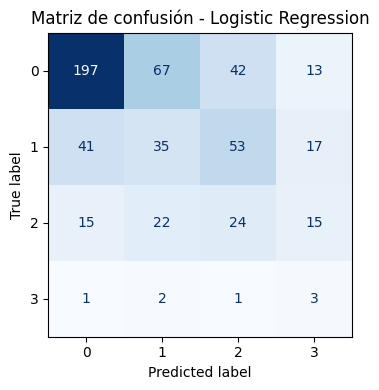

In [13]:
# Matriz de confusión - Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log,
    cmap='Blues', colorbar=False, ax=ax
)
plt.title('Matriz de confusión - Logistic Regression')
plt.tight_layout()
plt.show()


Logistic Regression fue utilizada como modelo baseline debido a su simplicidad e interpretabilidad.

El uso de class_weight='balanced' busca compensar parcialmente el desbalance presente en las clases del target.

### 17.4 Decision Tree

In [14]:
# ==================================================
# DECISION TREE (Pipeline)
# ==================================================

tree_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(
        max_depth=6,
        random_state=42,
        class_weight='balanced'
    ))
])

tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)

print("DECISION TREE")
print(f"Accuracy:          {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"F1 Macro:          {f1_score(y_test, y_pred_tree, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_tree):.4f}")
print(f"QWK (Cohen's k2):  {cohen_kappa_score(y_test, y_pred_tree, weights='quadratic'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))


DECISION TREE
Accuracy:          0.4818
F1 Macro:          0.3445
Balanced Accuracy: 0.4737
QWK (Cohen's k2):  0.3490

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.60      0.68       319
           1       0.31      0.33      0.32       146
           2       0.22      0.25      0.23        76
           3       0.08      0.71      0.14         7

    accuracy                           0.48       548
   macro avg       0.35      0.47      0.34       548
weighted avg       0.57      0.48      0.52       548



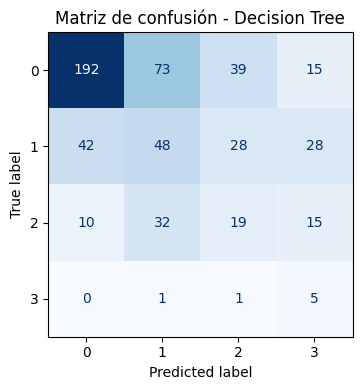

In [15]:
# Matriz de confusión - Decision Tree
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tree,
    cmap='Blues', colorbar=False, ax=ax
)
plt.title('Matriz de confusión - Decision Tree')
plt.tight_layout()
plt.show()


Decision Tree permite capturar relaciones no lineales entre variables y suele adaptarse mejor a datasets heterogéneos que modelos lineales simples.

### 17.5 Random Forest

In [16]:
# ==================================================
# RANDOM FOREST (Pipeline)
# ==================================================

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("RANDOM FOREST")
print(f"Accuracy:          {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 Macro:          {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_rf):.4f}")
print(f"QWK (Cohen's k2):  {cohen_kappa_score(y_test, y_pred_rf, weights='quadratic'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


RANDOM FOREST
Accuracy:          0.5821
F1 Macro:          0.3627
Balanced Accuracy: 0.3659
QWK (Cohen's k2):  0.4036

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       319
           1       0.37      0.36      0.36       146
           2       0.33      0.36      0.34        76
           3       0.00      0.00      0.00         7

    accuracy                           0.58       548
   macro avg       0.36      0.37      0.36       548
weighted avg       0.57      0.58      0.58       548



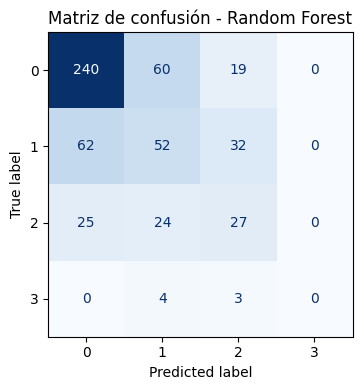

In [17]:
# Matriz de confusión - Random Forest
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    cmap='Blues', colorbar=False, ax=ax
)
plt.title('Matriz de confusión - Random Forest')
plt.tight_layout()
plt.show()


Random Forest fue seleccionado debido a su capacidad para manejar relaciones complejas, variables heterogéneas y reducir overfitting mediante ensambles de múltiples árboles.

### 17.6 Validación cruzada estratificada

Una sola partición train/test puede dar resultados muy variables, sobre todo con clases minoritarias (clase 3 ≈ 1%). Validamos los modelos con `StratifiedKFold(n_splits=5, shuffle=True)` y reportamos `F1 Macro` y `Balanced Accuracy` como `media ± std` para tener una estimación más estable del desempeño.

Como cada modelo está envuelto en un `Pipeline` con su preprocesador, `cross_val_score` re-ajusta correctamente la imputación y el `OneHotEncoder` **dentro de cada fold**, sin contaminar el conjunto de validación.

In [18]:
# ==================================================
# VALIDACIÓN CRUZADA ESTRATIFICADA (5 folds)
# ==================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = {
    'Dummy (most_frequent)': dummy_pipeline,
    'Logistic Regression':   log_pipeline,
    'Decision Tree':         tree_pipeline,
    'Random Forest':         rf_pipeline,
}

filas_cv = []
for nombre, pipe in modelos_cv.items():
    f1_scores  = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro',         n_jobs=-1)
    bal_scores = cross_val_score(pipe, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    qwk_scores = cross_val_score(pipe, X, y, cv=cv, scoring=qwk_scorer,          n_jobs=-1)
    filas_cv.append({
        'Modelo':             nombre,
        'F1 Macro (μ±σ)':     f'{f1_scores.mean():.4f} ± {f1_scores.std():.4f}',
        'Balanced Acc (μ±σ)': f'{bal_scores.mean():.4f} ± {bal_scores.std():.4f}',
        'QWK (μ±σ)':          f'{qwk_scores.mean():.4f} ± {qwk_scores.std():.4f}',
    })

cv_df = pd.DataFrame(filas_cv)
print("Resultados de validación cruzada (5 folds estratificados):")
print(cv_df.to_string(index=False))


Resultados de validación cruzada (5 folds estratificados):
               Modelo  F1 Macro (μ±σ) Balanced Acc (μ±σ)       QWK (μ±σ)
Dummy (most_frequent) 0.1841 ± 0.0001    0.2500 ± 0.0000 0.0000 ± 0.0000
  Logistic Regression 0.3570 ± 0.0206    0.4155 ± 0.0644 0.3779 ± 0.0224
        Decision Tree 0.3396 ± 0.0189    0.4007 ± 0.0485 0.3252 ± 0.0288
        Random Forest 0.3439 ± 0.0197    0.3440 ± 0.0183 0.3816 ± 0.0409


## 18. Comparación de Modelos

In [19]:
# ==================================================
# COMPARACIÓN DE MODELOS
# ==================================================

predicciones = {
    'Dummy (most_frequent)': y_pred_dummy,
    'Logistic Regression':   y_pred_log,
    'Decision Tree':         y_pred_tree,
    'Random Forest':         y_pred_rf,
}

comparacion_modelos = pd.DataFrame({
    'Modelo':            list(predicciones.keys()),
    'Accuracy':          [accuracy_score(y_test, p)                            for p in predicciones.values()],
    'F1 Macro':          [f1_score(y_test, p, average='macro')                 for p in predicciones.values()],
    'Balanced Accuracy': [balanced_accuracy_score(y_test, p)                   for p in predicciones.values()],
    'QWK':               [cohen_kappa_score(y_test, p, weights='quadratic')    for p in predicciones.values()],
}).round(4)

comparacion_modelos


,Modelo,Accuracy,F1 Macro,Balanced Accuracy,QWK
0,Dummy (most_frequent),0.5821,0.1840,0.2500,0.0000
1,Logistic Regression,0.4726,0.3247,0.4004,0.3429
2,Decision Tree,0.4818,0.3445,0.4737,0.3490
3,Random Forest,0.5821,0.3627,0.3659,0.4036


### 18.1 Visualización comparativa

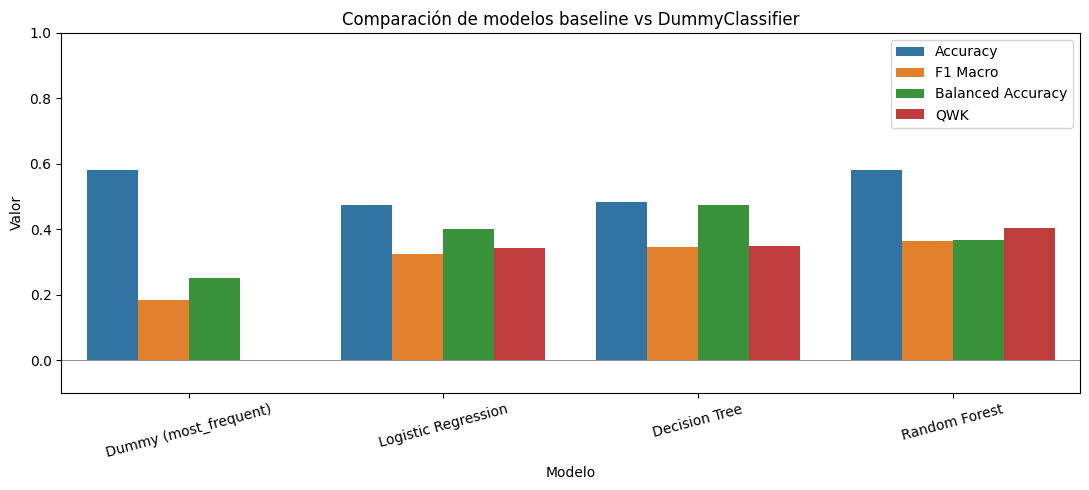

In [20]:
comparacion_long = comparacion_modelos.melt(
    id_vars='Modelo',
    value_vars=['Accuracy', 'F1 Macro', 'Balanced Accuracy', 'QWK'],
    var_name='Métrica',
    value_name='Valor'
)

plt.figure(figsize=(11,5))
sns.barplot(data=comparacion_long, x='Modelo', y='Valor', hue='Métrica')
plt.title('Comparación de modelos baseline vs DummyClassifier')
plt.ylim(-0.1, 1)
plt.axhline(0, color='gray', linewidth=0.6)
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


Por el fuerte desbalance de clases, `Accuracy` puede ser engañosa: el `DummyClassifier` (que siempre predice la clase mayoritaria) alcanza un *accuracy* cercano a `0.58`, igual a la proporción de la clase 0. `F1 Macro` y `Balanced Accuracy` son métricas más adecuadas porque ponderan por igual cada clase.

**Cohen's Quadratic Weighted Kappa (QWK)** es la **métrica oficial** de la competición Kaggle. A diferencia de las anteriores, QWK aprovecha la naturaleza **ordinal** del target: predecir clase 3 cuando el real es 0 se penaliza más fuerte que predecir clase 1 cuando el real es 0. QWK está acotado en `[-1, 1]`, donde `0` corresponde a un acuerdo igual al azar y `1` al acuerdo perfecto. Por construcción, el `DummyClassifier` obtiene `QWK = 0` (siempre predice la mayoritaria, no captura ningún orden).

Los tres modelos baseline (`Logistic Regression`, `Decision Tree`, `Random Forest`) superan al `DummyClassifier` en `F1 Macro`, `Balanced Accuracy` y `QWK`, lo que confirma que aprenden información útil del dataset. Random Forest es el mejor de los tres en esta primera iteración, aunque la diferencia con Decision Tree es pequeña y todos los modelos siguen siendo modestos en términos absolutos. Las mejoras QWK (ensemble ordinal) se documentan en el notebook 04; el tuning y la síntesis final en el notebook 05 y en `python -m src.main tune`.

## 19. Importancia de Variables

### 19.1 Feature Importance con Random Forest

In [21]:
# ==================================================
# FEATURE IMPORTANCE (Random Forest dentro del Pipeline)
# ==================================================
# El preprocesador genera nombres de columnas con prefijos "num__" / "cat__".
# Los recuperamos con get_feature_names_out() y limpiamos para legibilidad.

feature_names_raw = rf_pipeline.named_steps['prep'].get_feature_names_out()
feature_names = [f.split('__', 1)[-1] for f in feature_names_raw]

importance_df = pd.DataFrame({
    'Variable':    feature_names,
    'Importancia': rf_pipeline.named_steps['clf'].feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(importance_df.head(15).to_string(index=False))


                              Variable  Importancia
                       Physical-Height     0.049209
                       Basic_Demos-Age     0.047722
                       Physical-Weight     0.046121
                       SDS-SDS_Total_T     0.041314
                     SDS-SDS_Total_Raw     0.039086
                           BIA-BIA_SMM     0.034762
                          Physical-BMI     0.033837
PreInt_EduHx-computerinternet_hoursday     0.031972
                  Physical-Systolic_BP     0.028868
                           BIA-BIA_DEE     0.027179
                           BIA-BIA_LDM     0.026885
                           BIA-BIA_TBW     0.025853
                    Physical-HeartRate     0.025755
                           BIA-BIA_ICW     0.025106
                       CGAS-CGAS_Score     0.024747


### 19.2 Visualización

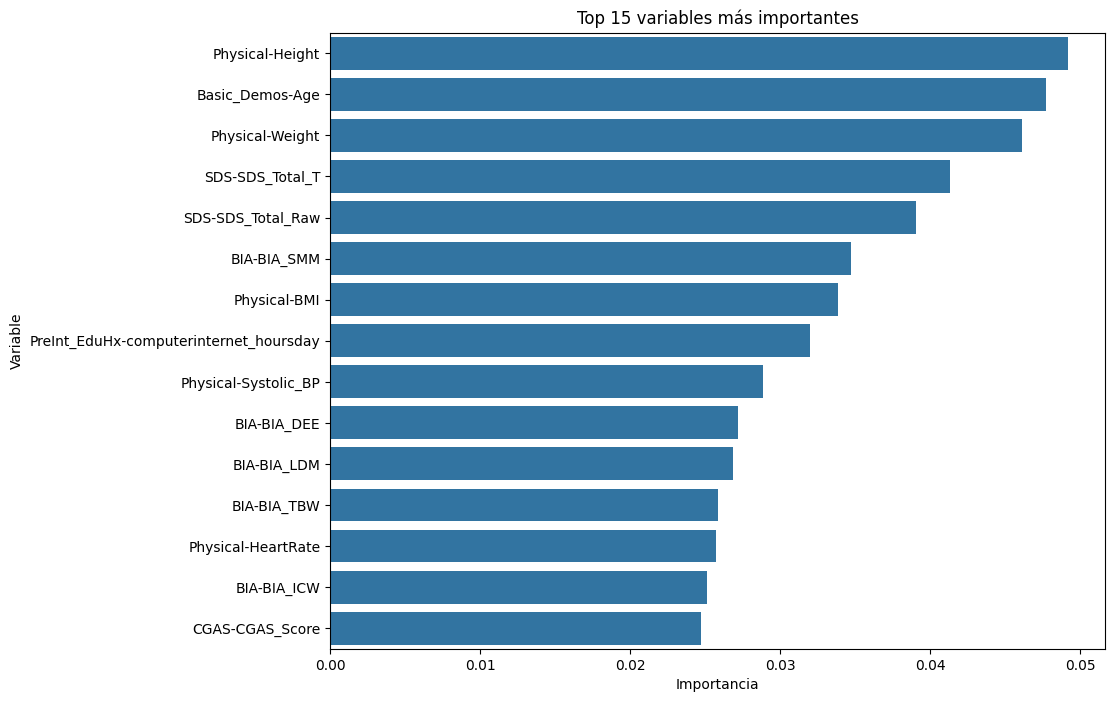

In [22]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df.head(15),
    x='Importancia',
    y='Variable'
)

plt.title('Top 15 variables más importantes')

plt.show()


Entre las variables con mayor importancia (basada en impureza, Random Forest) destacan métricas físicas y antropométricas (`Physical-Height`, `Physical-Weight`, `Physical-BMI`, `BIA-BIA_SMM`), variables demográficas (`Basic_Demos-Age`), de sueño (`SDS-SDS_Total_Raw`, `SDS-SDS_Total_T`), de hábitos digitales (`PreInt_EduHx-computerinternet_hoursday`) y de actividad física (`PAQ_C-PAQ_C_Total`).

Esta lista es **consistente** con la hipótesis principal: las familias de variables relacionadas con condición física, sueño y hábitos digitales aparecen todas en los primeros puestos. No obstante, conviene tener varias precauciones al interpretar este resultado:

- La importancia por impureza tiende a inflarse en variables con muchas categorías o gran rango numérico, por lo que `Physical-Height` y `Basic_Demos-Age` pueden estar parcialmente sobrerrepresentadas.
- La importancia describe **uso interno del modelo**, no causalidad: indica qué variables ayudan a partir el espacio, no que provoquen un mayor `sii`.
- Como complemento, conviene comparar con `permutation_importance` (incluido en el pipeline) y/o SHAP para validar la robustez del ranking.

Aun con estas reservas, la convergencia entre la familia de variables priorizadas por el modelo y las hipótesis planteadas refuerza la pertinencia de seguir trabajando con este conjunto de features.

### 19.3 Permutation importance (validación del ranking)

La importancia por impureza puede estar sesgada hacia variables continuas con muchos valores únicos. La *permutation importance* mide la caída real del desempeño al permutar aleatoriamente cada variable: si la métrica cae mucho, la variable es genuinamente útil.

**Importante:** se usa `QWK` (Quadratic Weighted Kappa) como scoring para la permutación, ya que es la **métrica oficial** de la competición y reconoce la naturaleza ordinal del target. Usar `F1 Macro` (que trata las clases como nominales) podría dar un ranking diferente.

Top 15 - Permutation importance (caída de QWK al permutar)
                              Variable  Permutación      Std
                       Basic_Demos-Age     0.044081 0.013805
                       Physical-Height     0.029689 0.020546
                       Physical-Weight     0.026220 0.020594
PreInt_EduHx-computerinternet_hoursday     0.019985 0.011045
                          FGC-FGC_GSND     0.019918 0.006770
                            SDS-Season     0.012591 0.010916
                     PAQ_C-PAQ_C_Total     0.012403 0.006892
                          PAQ_C-Season     0.008323 0.007558
                       SDS-SDS_Total_T     0.007758 0.013335
                       Basic_Demos-Sex     0.006186 0.009629
                       CGAS-CGAS_Score     0.005969 0.008046
                     SDS-SDS_Total_Raw     0.005633 0.010916
                           FGC-FGC_GSD     0.003838 0.007355
                 Physical-Diastolic_BP     0.002876 0.010873
                     FGC-F

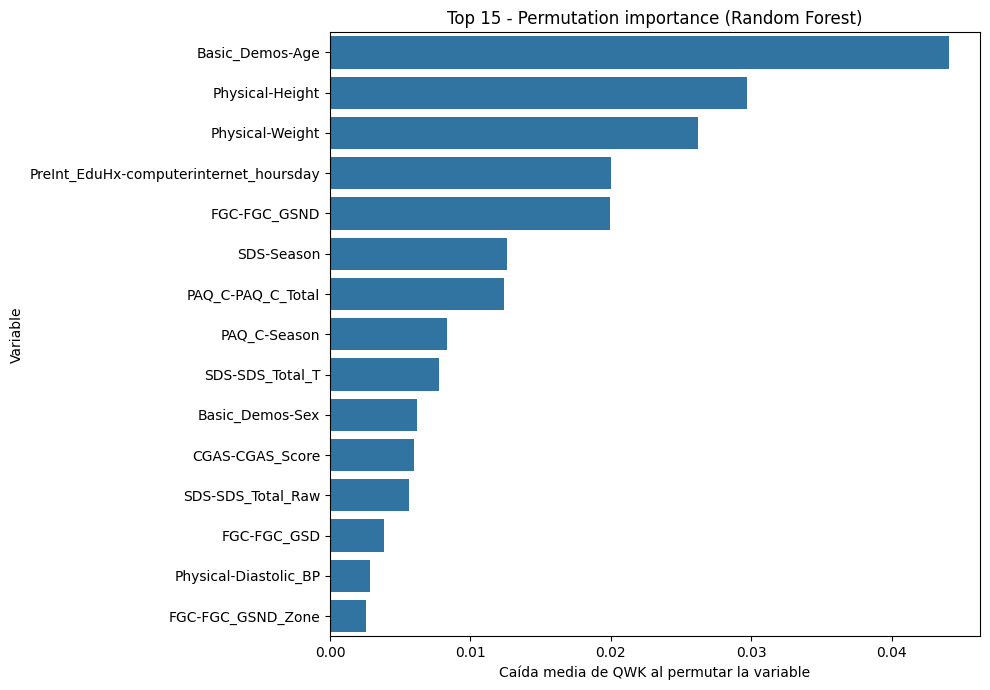

In [23]:
# ==================================================
# PERMUTATION IMPORTANCE (Random Forest sobre el test set)
# ==================================================

# Usamos QWK como scoring (métrica oficial de la competición)
# en lugar de f1_macro para que el ranking de variables sea
# consistente con el objetivo del proyecto.
perm_result = permutation_importance(
    rf_pipeline, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring=qwk_scorer,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'Variable':    X.columns,
    'Permutación': perm_result.importances_mean,
    'Std':         perm_result.importances_std,
}).sort_values('Permutación', ascending=False)

print("Top 15 - Permutation importance (caída de QWK al permutar)")
print(perm_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 7))
sns.barplot(data=perm_df.head(15), x='Permutación', y='Variable')
plt.title('Top 15 - Permutation importance (Random Forest)')
plt.xlabel('Caída media de QWK al permutar la variable')
plt.tight_layout()
plt.show()


## 20. Conclusiones Parciales

**Sobre los datos**

*   El dataset es un problema de clasificación multiclase fuertemente desbalanceado: la clase 0 representa ~58%, la clase 1 ~27%, la clase 2 ~14% y la clase 3 ~1%. Por esto trabajamos con `class_weight='balanced'` y reportamos `F1 macro` y `balanced_accuracy` además de `accuracy`.
*   Las variables `PCIAT-*` se identificaron como leakage (correlación con `sii` cercana a `0.90`) y se removieron del dataset de modelado.
*   Tras la limpieza (sin filas con `sii` nulo, sin `PCIAT`, sin columnas con >70% nulos) se trabaja con `2,736` registros y `53` columnas.
*   Las variables ordinales codificadas como entero (`Sex`, zonas FGC, `BIA_Activity_Level`, `computerinternet_hoursday`) se tratan aparte de las numéricas continuas en el preprocesador: se imputan por moda y no se escalan, para preservar su semántica ordinal/categórica.

**Sobre el EDA y las hipótesis**

*   La hipótesis principal — que mayor uso problemático de internet se asocia con menor actividad física, peor condición física y peor calidad de sueño — es **plausible** a la luz de las correlaciones post-limpieza, los boxplots por nivel de `sii` y la importancia de variables del Random Forest.
*   Los tests de **Kruskal-Wallis** (sección 12.5) respaldan formalmente las diferencias entre grupos de `sii` para las variables ligadas a las hipótesis (horas de internet, BMI, sueño).
*   **Nota sobre `PAQ_C-PAQ_C_Total`:** no rechaza H₀ en el test de Kruskal-Wallis (p = 0.876). Esto puede deberse a que la variable tiene 56.5% de nulos (sesgo de selección en quiénes respondieron) y a que solo aplica a niños (no adolescentes), subgrupo donde el PIU severo es menos prevalente. No invalida la hipótesis general sino que sugiere que la relación actividad física → PIU puede estar mediada por la edad.
*   Las correlaciones lineales con `sii` (después de remover el leakage) son **moderadas o bajas**, lo cual es consistente con un fenómeno multifactorial y refuerza la necesidad de modelos no lineales.
*   Algunas variables conceptualmente clave para la consigna (`PAQ_A-*`, `Fitness_Endurance-*`) se descartan por exceso de nulos; esto se reconoce como una limitación a documentar.

**Sobre los modelos baseline**

*   `DummyClassifier` (predecir siempre la mayoritaria) marca el piso de comparación.
*   `Logistic Regression`, `Decision Tree` y `Random Forest` superan a la baseline ingenua en `F1 macro` y `balanced_accuracy`, aunque la mejora absoluta sigue siendo moderada.
*   La convergencia de `Logistic Regression` fue verificada explícitamente para asegurar que las métricas reportadas provienen de un modelo completamente entrenado.
*   La **validación cruzada estratificada** (sección 17.6) confirma el ranking observado en la partición 80/20 y entrega un margen de variación realista (`media ± std` por modelo) para cada métrica.
*   La **`permutation_importance`** (sección 19.3) se calculó usando **QWK** como métrica (la oficial de la competición), y corrobora a las variables físicas, demográficas y de hábitos digitales como las más útiles, sin la inflación que la importancia por impureza tiende a introducir en variables continuas con mucho rango.
*   Random Forest es el mejor modelo preliminar, pero su `accuracy` aún es comparable a la del `DummyClassifier`, lo que se debe al desbalance: las métricas adecuadas (F1 macro / balanced accuracy / matrices de confusión) muestran que sí está aprendiendo.
*   La clase 3 (≈34 registros, ~1%) sigue siendo prácticamente indetectable con la cantidad de datos actual; su `recall` por clase debe interpretarse con mucha cautela.

**Próximos pasos**

*   **Métrica oficial.** Optimizar directamente para **Cohen's Quadratic Weighted Kappa (QWK)** durante el tuning, ya que es la métrica oficial de la competición y reconoce la naturaleza ordinal del target (no solo `F1 Macro` / `balanced_accuracy`).
*   **Modelos de gradient boosting.** Probar `LightGBM`, `XGBoost` y `CatBoost`, que son los modelos que dominan este dataset según la literatura sobre el reto y manejan bien valores faltantes y variables heterogéneas.
*   **Tratamiento ordinal del target.** Modelar `sii` como regresión continua (`0`–`3`) con umbrales optimizados sobre QWK, o usar modelos ordinales propios (`mord`, `OrderedModel` de `statsmodels`).
*   **Imputación avanzada.** Reemplazar la mediana/moda por `KNNImputer`, `IterativeImputer` (MICE) o multiple imputation, especialmente para variables conceptualmente clave con alto porcentaje de nulos (p. ej. `PAQ_C-PAQ_C_Total`).
*   **Estrategias de balanceo.** Además de `class_weight='balanced'`, evaluar `SMOTE`, `ADASYN`, `class_weight='balanced_subsample'` y la fusión de clases `2+3` para mitigar la escasez extrema de la clase severa.
*   **Aprendizaje semi-supervisado.** Aprovechar los ~30% de registros con `sii` nulo (hoy descartados) mediante *pseudolabeling* o *self-training* con el mejor modelo, técnica reportada por las soluciones medallistas en Kaggle.
*   **Datos de actigrafía.** Incorporar las series temporales de los 996 sujetos (~33%) usando: (a) features manuales (media, mediana, desviación, kurtosis, periodicidad, ratios actividad/inactividad) o (b) representaciones aprendidas con autoencoders / `LSTM` / `GRU`, combinando luego con los datos tabulares en un modelo híbrido.
*   **Ingeniería de features tabulares.** Interacciones entre variables (BMI · edad · horas de internet), transformaciones (`log`, `Box-Cox`) para variables muy asimétricas y agregaciones por familia (p. ej. índice resumen de FitnessGram).
*   **Validación robusta.** Mantener `StratifiedKFold` con múltiples seeds para reportar varianza realista, y usar QWK como `scoring` también dentro del tuning.